### This notebook compute "VCA10. Progress in Preparation of the Water Resources Management Plan for the basin" indicator for the 27 basins of IKI Project

Spanish: Avance en la elaboración del Plan de Gestión de Recursos Hídricos de la cuenca

**Created:** 11/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, Excel with status from ANA (Fronseca)

**Outputs:** Indicator score (0, 0.5, 1) for the CRHC's progress in the plan
 
**Assumptions:** Currently those subbasins with no data are assigned NaN. Determine whether to give this 0. 
 
**Future work:** 
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 510 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [ ]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in PGRH Excel
PGRH = rf'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Datos\Planes_Gestion\Estado de PGRH.xlsx'
pgrh_df = pd.read_excel(PGRH)

In [ ]:
#FORMAT DATAFRAME

#make second row the header
pgrh_df.columns = pgrh_df.iloc[1]
pgrh_df = pgrh_df[2:]

In [ ]:
#MAP PGRH STATUS TO SUBBASINS

# For each COMID in subbasin_gdf, add the estado del plan column based on matching cuencas, ignoring any differences in accents

import unicodedata

# Function to remove accents from strings
def remove_accents(text):
    if pd.isna(text):
        return text
    # Normalize to NFD (decomposed form) and filter out combining characters
    return ''.join(c for c in unicodedata.normalize('NFD', str(text)) 
                   if unicodedata.category(c) != 'Mn')

# Create normalized versions of the Cuenca column in both dataframes
# Remove "Cuenca" prefix from subbasins_gdf before normalizing
subbasins_gdf['Cuenca_normalized'] = (
    subbasins_gdf['Cuenca']
    .str.replace('Cuenca', '', case=False, regex=False)  # Remove "Cuenca" prefix
    .apply(remove_accents)
    .str.strip()
    .str.upper()
)

pgrh_df['Cuenca_normalized'] = (
    pgrh_df['Cuenca']
    .apply(remove_accents)
    .str.strip()
    .str.upper()
)

# Merge based on the normalized Cuenca column
subbasins_with_pgrh = subbasins_gdf.merge(
    pgrh_df[['Cuenca_normalized', 'Estado del Plan']], 
    on='Cuenca_normalized', 
    how='left'
)

# Drop the temporary normalized column
subbasins_with_pgrh = subbasins_with_pgrh.drop(columns=['Cuenca_normalized'])

# Display results
print(f"Total COMIDs: {len(subbasins_with_pgrh)}")
print(f"COMIDs with PGRH status: {subbasins_with_pgrh['Estado del Plan'].notna().sum()}")
print(f"\nPGRH Status Distribution:")
print(subbasins_with_pgrh['Estado del Plan'].value_counts())

Total COMIDs: 3655
COMIDs with PGRH status: 3533

PGRH Status Distribution:
Estado del Plan
Aprobado                   2255
No tiene                    908
Cuenta con algún avance     370
Name: count, dtype: int64


In [ ]:
# Assign scores based on "Estado del Plan"

def assign_pgrh_score(estado):
    if pd.isna(estado):
        return np.nan  # No plan
    estado_lower = str(estado).lower().strip()
    
    if 'aprobado' in estado_lower:
        return 1  # Plan approved/implemented
    elif 'cuenta con algún avance' in estado_lower or 'elaboracion' in estado_lower:
        return 0.5  # Plan in preparation
    elif 'no tiene' in estado_lower or 'sin' in estado_lower:
        return 0  # No plan
    else:
        return 0  # Assume if there is no data, no plan

# Apply scoring function
subbasins_with_pgrh['PGRH_Score'] = subbasins_with_pgrh['Estado del Plan'].apply(assign_pgrh_score)

# Display score distribution
print("\nPGRH Score Distribution:")
print(subbasins_with_pgrh['PGRH_Score'].value_counts().sort_index())
print(f"\nCOMIDs without PGRH data: {subbasins_with_pgrh['PGRH_Score'].isna().sum()}")


PGRH Score Distribution:
PGRH_Score
0.0     908
0.5     370
1.0    2255
Name: count, dtype: int64

COMIDs without PGRH data: 122


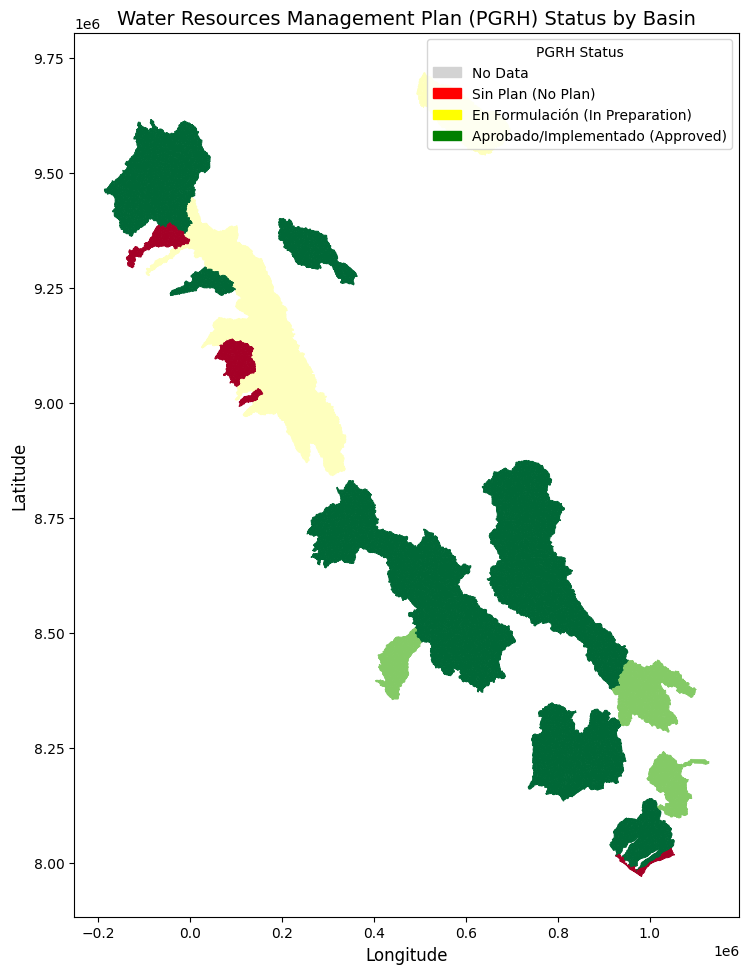

In [9]:
# Plot PGRH scores in map format
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 10))

# Create a temporary column for plotting that handles NaN
subbasins_with_pgrh['PGRH_Score_plot'] = subbasins_with_pgrh['PGRH_Score'].fillna(-1)

# Plot with custom colors
subbasins_with_pgrh.plot(column='PGRH_Score_plot', ax=ax, legend=False, 
                          cmap='RdYlGn', edgecolor='face', linewidth=0.5)

# Create custom legend
legend_labels = {
    -1: 'No Data',
    0: 'Sin Plan (No Plan)',
    0.5: 'En Formulación (In Preparation)',
    1: 'Aprobado/Implementado (Approved)'
}
colors = {-1: 'lightgrey', 0: 'red', 0.5: 'yellow', 1: 'green'}

# Create patches for the legend
patches = [mpatches.Patch(color=colors[key], label=legend_labels[key]) 
           for key in sorted(legend_labels.keys())]

# Add legend
ax.legend(handles=patches, loc='upper right', title='PGRH Status')

plt.title('Water Resources Management Plan (PGRH) Status by Basin', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()

SQLITE INSERT 

In [10]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_with_pgrh #COMID and PMACC_Score
value_column= 'PGRH_Score' #Column with calculated indicator values

In [11]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [12]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [14]:
rows_to_insert

[(1, 510, 311153600, 0.5),
 (1, 510, 310832400, 0.5),
 (1, 510, 310825700, 0.5),
 (1, 510, 310282400, 0.5),
 (1, 510, 308754600, 1.0),
 (1, 510, 307736500, 0.0),
 (1, 510, 307078200, 0.0),
 (1, 510, 307183500, nan),
 (1, 510, 306538400, 1.0),
 (1, 510, 306599700, 1.0),
 (1, 510, 306319300, 0.0),
 (1, 510, 306030000, nan),
 (1, 510, 305746400, 1.0),
 (1, 510, 311953100, 1.0),
 (1, 510, 304273900, 0.0),
 (1, 510, 304281100, 0.0),
 (1, 510, 304281200, 0.0),
 (1, 510, 304379300, 0.0),
 (1, 510, 304274000, 0.0),
 (1, 510, 304313700, 0.0),
 (1, 510, 304306400, 0.0),
 (1, 510, 304327700, 0.0),
 (1, 510, 304313800, 0.0),
 (1, 510, 304306300, 0.0),
 (1, 510, 304321600, 0.0),
 (1, 510, 304321700, 0.0),
 (1, 510, 304339400, 0.0),
 (1, 510, 304335700, 0.0),
 (1, 510, 304343200, 0.0),
 (1, 510, 304343100, 0.0),
 (1, 510, 304335800, 0.0),
 (1, 510, 304343000, 0.0),
 (1, 510, 304330900, 0.0),
 (1, 510, 304352700, 0.0),
 (1, 510, 304421200, 0.0),
 (1, 510, 304403000, 0.0),
 (1, 510, 304352600, 0.0),
 

In [13]:
#summarize statistics for rows_to_insert
df_check.describe()

,ScnID,IndID,COMID,Value
count,3655.0,3655.0,3.655000e+03,3533.000000
mean,1.0,510.0,3.085487e+08,0.690631
std,0.0,0.0,2.145454e+06,0.433049
min,1.0,510.0,3.042739e+08,0.000000
25%,1.0,510.0,3.066237e+08,0.000000
50%,1.0,510.0,3.091100e+08,1.000000
75%,1.0,510.0,3.102598e+08,1.000000
max,1.0,510.0,3.202546e+08,1.000000


In [15]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()